In [1]:
import pandas as pd


In [3]:
base_professores = pd.read_csv('/content/base_professores.csv')
base_docs = pd.read_csv('/content/base_doutorandos.csv')
base_pos_docs = pd.read_csv('/content/base_posdocs.csv')
gender = pd.read_csv('/content/Genero.csv')
base_geral = pd.read_csv('/content/Base_geral.csv')


In [4]:
base_professores = pd.merge(base_professores, gender, how='inner', on= "Pesquisador")
base_docs = pd.merge(base_docs, gender, how='inner', on= "Pesquisador")
base_pos_docs = pd.merge(base_pos_docs, gender, how='inner', on= "Pesquisador")

In [5]:

base_mulheres_profs = pd.DataFrame((base_professores.groupby('Gênero').get_group('F')).value_counts('Pesquisador').reset_index().rename(columns={0:'Artigos'}))
base_homens_profs = pd.DataFrame((base_professores.groupby('Gênero').get_group('M')).value_counts('Pesquisador').reset_index().rename(columns={0:'Artigos'}))

base_mulheres_docs = pd.DataFrame((base_docs.groupby('Gênero').get_group('F')).value_counts('Pesquisador').reset_index().rename(columns={0:'Artigos'}))
base_homens_docs = pd.DataFrame((base_docs.groupby('Gênero').get_group('M')).value_counts('Pesquisador').reset_index().rename(columns={0:'Artigos'}))

base_mulheres_PosDocs = pd.DataFrame((base_pos_docs.groupby('Gênero').get_group('F')).value_counts('Pesquisador').reset_index().rename(columns={0:'Artigos'}))
base_homens_PosDocs = pd.DataFrame((base_pos_docs.groupby('Gênero').get_group('M')).value_counts('Pesquisador').reset_index().rename(columns={0:'Artigos'}))


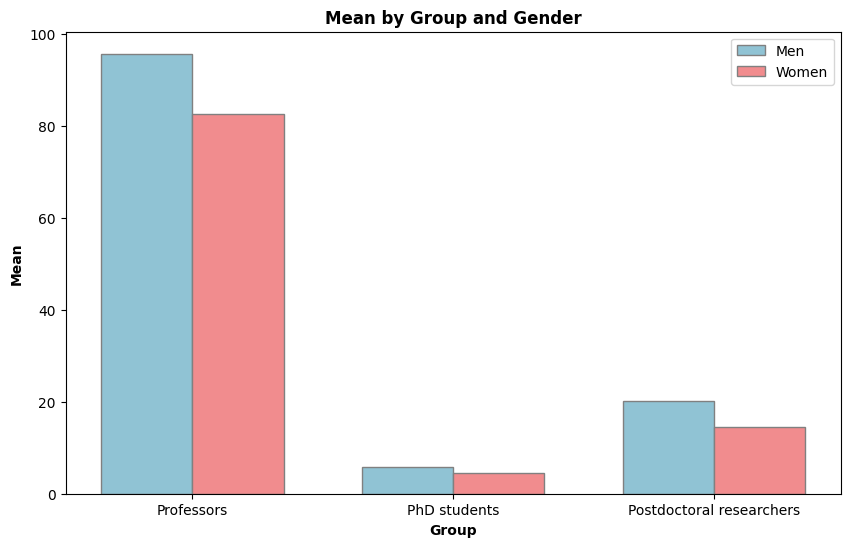

In [6]:
import pandas as pd
import matplotlib.pyplot as plt


data = {
    'Group': ['Professors', 'Professors', 'PhD students', 'PhD students', 'Postdoctoral researchers', 'Postdoctoral researchers'],
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'Mean': [95.65789473684211, 82.60714285714286, 5.779411764705882
, 4.5, 20.236842105263158, 14.542857142857143]
}

df = pd.DataFrame(data)

# Create a grouped bar plot
plt.figure(figsize=(10, 6))

# Filter data by gender
men = df[df['Gender'] == 'Male']
women = df[df['Gender'] == 'Female']

# Get unique groups
groups = df['Group'].unique()

# Set bar width
bar_width = 0.35

# Set bar positions
r1 = range(len(groups))
r2 = [x + bar_width for x in r1]

# Plot bars for men and women with lighter colors
plt.bar(r1, men['Mean'], color='#90C3D4', width=bar_width, edgecolor='grey', label='Men')
plt.bar(r2, women['Mean'], color='#F18C8E', width=bar_width, edgecolor='grey', label='Women')

# Add labels, titles, and legends in English
plt.xlabel('Group', fontweight='bold')
plt.ylabel('Mean', fontweight='bold')
plt.xticks([r + bar_width / 2 for r in range(len(groups))], groups)
plt.title('Mean by Group and Gender', fontweight='bold')
plt.legend()

# Display the plot
plt.show()